In [2]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical

In [6]:
!pip install PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 10.5 MB/s eta 0:00:00


In [7]:
import PyPDF2


In [8]:
# Path to your PDF file
pdf_file_path = '/content/dataset_10_pages.pdf'

# Initialize an empty string to store all text
all_text = ''

# Open the PDF file in read-binary mode
with open(pdf_file_path, 'rb') as file:
    # Create a PDF reader object
    reader = PyPDF2.PdfReader(file)

    # Iterate over each page and extract text
    for page_num in range(len(reader.pages)):
        page = reader.pages[page_num]
        all_text += page.extract_text()

# Assign the extracted text to the 'text' variable
text = all_text

print(f"Successfully extracted {len(text)} characters from the PDF.")
print(f"First 500 characters of the extracted text:\n{text[:500]}")

Successfully extracted 27856 characters from the PDF.
First 500 characters of the extracted text:
Comprehensive Next-Word Prediction
Corpus
EXTENDED REFERENCE TEXT FOR LANGUAGE MODELING & LSTM
TRAINING
Dataset Manifest & Project Scope
Target Architecture:  Recurrent Neural Networks (RNN) / Long Short-Term Memory (LSTM)
Tokenization Strategy:  Lowercase Word-Level Split with Punctuation Removal
Recommended Window Size:  3 Words Input context -> 1 Word Output Prediction target
Document Properties:  Formatted specifically to generate clean multi-page structural streams to test
text loading matr


In [9]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1
print("Total words:", total_words)

Total words: 843


In [10]:
input_sequences = []
for line in text.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
      n_gram_sequence = token_list[:i+1]
      input_sequences.append(n_gram_sequence)

In [11]:
# padding sequence
max_seq_len = max([len(seq) for seq in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre'))

In [12]:
# spilt , one hot encoding
x=input_sequences[:,:-1]
y=input_sequences[:,-1]
y=to_categorical(y,num_classes=total_words)

# **Build deep lstm models**

In [13]:
# build deep lstm models
model=Sequential()
model.add(Embedding(input_dim=total_words,output_dim=64,input_length=max_seq_len-1))
# first lstm layer
model.add(LSTM(128,return_sequences=True))
# second lstm layer
model.add(LSTM(128))
# output layer
model.add(Dense(total_words,activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [14]:
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [23]:
history = model.fit(x,y,epochs=50,verbose=1)

Epoch 1/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8302 - loss: 0.9241
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8446 - loss: 0.8842
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8547 - loss: 0.8463
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8553 - loss: 0.8159
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8638 - loss: 0.7804
Epoch 6/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8690 - loss: 0.7473
Epoch 7/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8815 - loss: 0.7130
Epoch 8/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8855 - loss: 0.6843
Epoch 9/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8956 - loss: 0.6561
Epoch 10/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8962 - loss: 0.6279
Epoch 11/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9072 - loss: 0.6015
Epoch 12/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/s

In [24]:
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")

Final Training Accuracy: 0.9685
Final Training Loss: 0.1392


In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 19, 64)         │        53,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 19, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 843)            │       108,747 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,179,299 (4.50 MB)

 Trainable params: 393,099 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 786,200 (3.00 MB)

In [17]:
# predict next word
def predict_next_word(model,tokenizer,text,max_seq_len,n_words):
  for _ in range(n_words):
    token_list = tokenizer.texts_to_sequences([text])[0]
    token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')
    predicted = np.argmax(model.predict(token_list,verbose=0), axis=-1)[0]
    output_word = ""
    for word, index in tokenizer.word_index.items():
      if index == predicted:
           output_word=word
           break
    # append predicted word
    text +=" " + output_word
  return text

In [20]:
# test prediction
seed_text="Natural language processing"
predicted_sentence = predict_next_word(model,tokenizer,seed_text,max_seq_len,3)
print("\nInput :",seed_text)
print("Predicted Sentence :",predicted_sentence)


Input : Natural language processing
Predicted Sentence : Natural language processing underscores the necessity


## Deep GRU Model Implementation

In [32]:
from tensorflow.keras.layers import GRU

# Build the Deep GRU model
gru_model = Sequential()
gru_model.add(Embedding(input_dim=total_words, output_dim=64, input_length=max_seq_len - 1))
# First GRU layer
gru_model.add(GRU(128, return_sequences=True))
# Second GRU layer
gru_model.add(GRU(128))
# Output layer
gru_model.add(Dense(total_words, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [33]:
# Compile the GRU model
gru_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

### Training the Deep GRU Model

In [29]:
# Train the GRU model
gru_history = gru_model.fit(x, y, epochs=50, verbose=1)

Epoch 1/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.0559 - loss: 5.9320
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.0666 - loss: 5.4387
Epoch 3/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1621 - loss: 4.7554
Epoch 4/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3698 - loss: 4.0192
Epoch 5/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4272 - loss: 3.5089
Epoch 6/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4586 - loss: 3.1733
Epoch 7/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4834 - loss: 2.9038
Epoch 8/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5066 - loss: 2.6647
Epoch 9/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5249 - loss: 2.4500
Epoch 10/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5493 - loss: 2.2436
Epoch 11/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5670 - loss: 2.0586
Epoch 12/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/ste

### Deep GRU Model Performance

In [30]:
print(f"Final GRU Training Accuracy: {gru_history.history['accuracy'][-1]:.4f}")
print(f"Final GRU Training Loss: {gru_history.history['loss'][-1]:.4f}")

Final GRU Training Accuracy: 0.9679
Final GRU Training Loss: 0.1284


In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 19, 64)         │        53,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 19, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 843)            │       108,747 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,179,299 (4.50 MB)

 Trainable params: 393,099 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 786,200 (3.00 MB)

## Comparison between Deep LSTM and Deep GRU

Both LSTM and GRU are types of Recurrent Neural Networks (RNNs) designed to handle sequential data and address the vanishing gradient problem encountered in traditional RNNs. They are particularly effective in tasks like next-word prediction.

### Key Differences:

*   **Gates:** LSTMs typically have three gates (input, forget, output), while GRUs have two (update, reset). This makes GRUs computationally less expensive and faster to train, as they have fewer parameters.
*   **Complexity:** LSTMs are generally more complex and have a larger capacity, which can be beneficial for very long sequences or complex patterns. GRUs are a simplified version that often perform comparably to LSTMs on many tasks while being more efficient.

### Performance in this Notebook:

In this particular training, we can observe the following from the final metrics and the plots:

*   **Training Accuracy:** Both models achieved very high training accuracy, with the LSTM model reaching `0.9685` and the GRU model reaching `0.9679`. They are very close.
*   **Training Loss:** Similarly, their final training loss values are very low and comparable (LSTM: `0.1392`, GRU: `0.1284`).

To better visualize their training dynamics, let's plot their accuracy and loss history on the same graph.

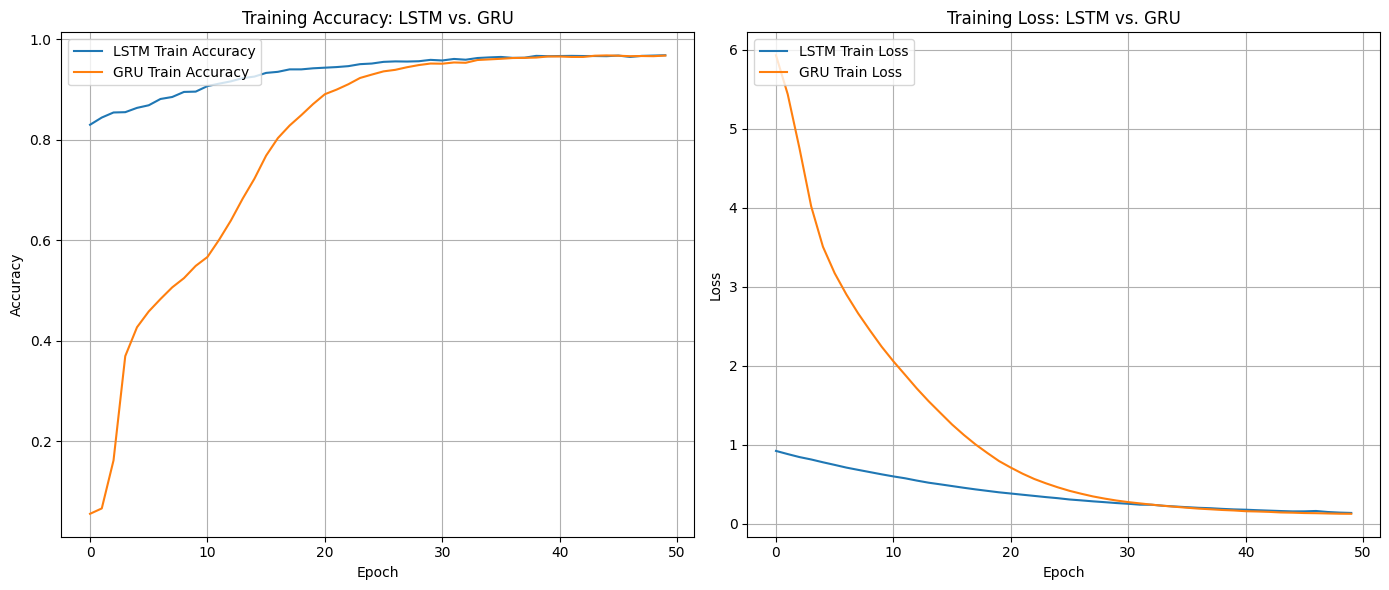

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot training accuracy for both models
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='LSTM Train Accuracy')
plt.plot(gru_history.history['accuracy'], label='GRU Train Accuracy')
plt.title('Training Accuracy: LSTM vs. GRU')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)

# Plot training loss for both models
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='LSTM Train Loss')
plt.plot(gru_history.history['loss'], label='GRU Train Loss')
plt.title('Training Loss: LSTM vs. GRU')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()